## 1.3 Interpolation d'une fonction continue

Soit $f: \mathbf [a,b] \rightarrow R$ continue et $x_0,\ldots,x_n\in [a,b]$ des noeuds distincts. Le polynôme d'interpolation
$\Pi_n(x)$ est noté $\Pi_n f(x)$ et est appelé <font color=blue>l'interpolant de $f$ aux
noeuds $x_0,\dots,x_n$</font>.


Si on prend $$y_k=f(x_k), k= 0,..., n,$$ 
alors on aura
\begin{equation*}
\Pi_nf(x)=\sum_{k=0}^n
f(x_k)\varphi_k(x).
\end{equation*}

#### Exercice

Ecrivez une fonction Python qui a la définition suivante, en utilisant la fonction `phi` définie plus haut.
Ecrivez aussi un petit test sur la base de l'exercice précédent.

```python
# Lagrange Interpolation of data (x,y), evaluated at ordinate(s) z
def LagrangePi(x,y,z):
    # the input variables are:
    # x : the interpolatory points
    # y : the corresponding data at the points x
    # z : where to evaluate the function
  
```

Utilisez le fait que $\{\varphi_k, k = 0,...,n\}$ est une base des polynômes de degré $\leq n$
et que le vecteur $y$ représente les coordonnées du polynôme d'interpolation recherché par rapport à cette base,
c'est-à-dire
$$\Pi_n (z) = y_0 \varphi_0 + ... + y_n \varphi_n$$




In [5]:
# importing libraries used in this book
import numpy as np
import matplotlib.pyplot as plt

from InterpolationLib import LagrangeBasis as phi

In [6]:
# Lagrange Interpolation of data (x,y), evaluated at ordinate(s) z
def LagrangePi(x,y,z):
    # the input variables are:
    # x : the interpolatory points
    # y : the corresponding data at the points x
    # z : where to evaluate the function
    
    # {phi(x,k,.), k=0,...,n} is a basis of the polynomials of degree n
    # y represents the coordinates of the interpolating polynomial with respect to this basis.
    # Therefore LagrangePi(x,y,.) = y[0] phi(x,0,.) + ... + y[n] phi(x,n,.)

    # >>> COMPLETE HERE <<<

    result = np.zeros_like(z)

    for k in range(np.size(y)):
        result = result +y[k]*phi(x,k,z)

    return result

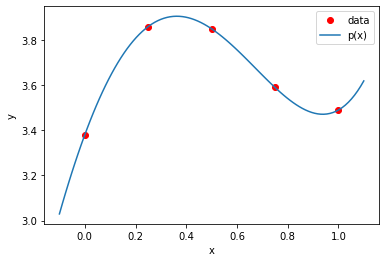

In [7]:
# vecteur des points d'interpolation
x = np.linspace(0, 1, 5)

# vecteur des valeurs
y = np.array([3.38, 3.86, 3.85, 3.59, 3.49])

z = np.linspace(-0.1, 1.1, 100)
plt.plot(x, y, 'ro', z, LagrangePi(x,y,z))

plt.xlabel('x'); plt.ylabel('y')
plt.legend(['data','p(x)'])
plt.show()


### Erreur d'interpolation

Soient $x_0$, $x_1$, $\ldots$, $x_n$,
$(n+1)$ nœuds *équirépartis* dans $I=[a,b]$ et soit $f\in C^{n+1}(I)$.
Alors
\begin{equation}
  \max_{x\in I} |f(x) - \Pi_n f(x)|  \leq \dfrac{1}{4(n+1)}
\left(\frac{b-a}{n}\right)^{n+1}\max_{x\in I}|f^{(n+1)}(x)|.
\end{equation}

On remarque que l'erreur d'interpolation dépend de la dérivée
$(n+1)$-ième de $f$.

#### Exercice

On considère les points d'interpolation $$x_0=1, x_1=1.75, x_2=2.5, x_3=3.25, x_4=4$$ 
et la fonction $$f(x) = x \sin(2\pi x)$$.

1. Calculez la base de Lagrange associée à ces points. D'abord sur papier, ensuite utilisez Python pour en dessiner le graphique.

2. Calculez le polynôme d'interpolation $\Pi_n$ à l'aide de la base de Lagrange. D'abord sur papier, ensuite avec Python.

4. Quelle est l'erreur théorique d'interpolation ? 




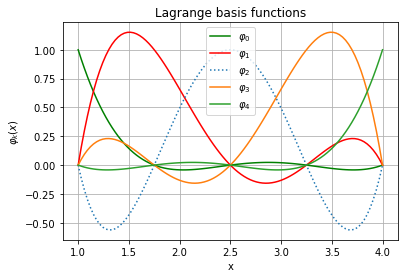

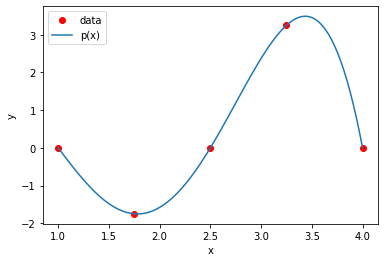

In [8]:
x = np.linspace(1.,4,5)
z = np.linspace(1., 4, 100)

plt.plot(z, phi(x,0,z), 'g', z, phi(x,1,z), 'r', z, phi(x,2,z),':',z,phi(x,3,z),z,phi(x,4,z))

plt.xlabel('x'); plt.ylabel('$\\varphi_{k}(x)$'); plt.title('Lagrange basis functions')
plt.legend(['$\\varphi_{0}$','$\\varphi_{1}$','$\\varphi_{2}$','$\\varphi_{3}$','$\\varphi_{4}$'])
plt.grid(True)
plt.show()

f = lambda x : x*np.sin(2*np.pi*x)

plt.plot(x, f(x), 'ro', z, LagrangePi(x,f(x),z))

plt.xlabel('x'); plt.ylabel('y')
plt.legend(['data','p(x)'])
plt.show()

#### Comportement pour $n$ grand: eg, la fonction de Runge.

Le fait que
$$\lim_{n\rightarrow\infty} \dfrac{1}{4(n+1)}\left(\dfrac{b-a}{n}\right)^{n+1}=0$$
n'implique pas forcément que $\max_{x \in I} |E_nf(x)|$ tende vers zéro quand $n\rightarrow\infty$.

Soit $f(x)=\dfrac{1}{1+x^2}$, $x\in [-5,5]$. Si on l'interpole dans des
noeuds équirépartis, l'interpolant présente des oscillations au voisinage des extrémités de l'intervalle.


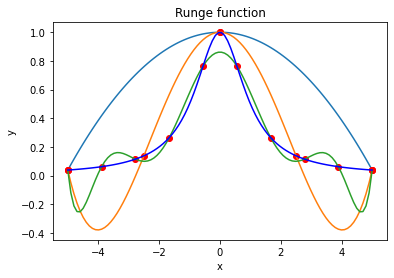

In [9]:
# Runge fonction
f = lambda x : 1./(1+x**2)

# Values of N to use
Nrange = [3,5,10]
# plotting points
z = np.linspace(-5, 5, 100)

for n in Nrange :

    # define x and y=f(x)
    # compute the Lagrange interpolant
    # plot it

    # >>> COMPLETE HERE <<<

    x = np.linspace(-5,5,n)
    y = f(x)
    plt.plot(x, f(x), 'ro', z, LagrangePi(x,f(x),z))
    plt.xlabel('x'); plt.ylabel('y')
    
    


plt.plot(z,f(z), 'b')
plt.xlabel('x'); plt.ylabel('y'); plt.title('Runge function')

plt.show()

`sympy` est une librairie pour le calcul symbolique en Python. Nous allons l'utiliser pour étudier le comportement de l'erreur d'interpolation de la fonction de Runge.

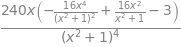

5th derivative evaluated at 3 :
-0.112320000000000


In [10]:
# Using symbolic python to compute derivatives
import sympy as sp

# define x as symbol
x = sp.symbols('x')

# define Runge function
f = 1/(1+x**2)

# pretty print the 5th derivative of f
f5 = sp.diff(f, x,5)
# display f5
sp.init_printing(use_unicode=True)
display(f5)


# evalf can be used to compute the value of a function at a given point
print('5th derivative evaluated at 3 :')
print( f5.evalf(subs={x: 3})  )


Pour définir une fonction qui accepte un array de valeur, il faut utiliser les lignes suivantes.

Ensuite on peut aussi dessiner le graphe ...

0.0102402235718104


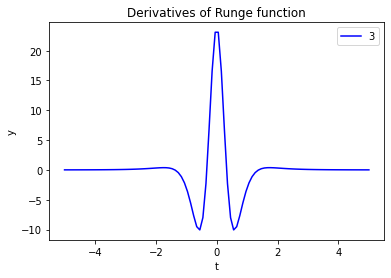

In [11]:

# to evaluate a function at many given points, we need the following trick
diff_f_func = lambda t: float(sp.diff(f,x,k).evalf(subs={x: t}))
diff_f = np.vectorize(diff_f_func)

# the derivative can be set with k (not very elegant...)
k = 4
print(diff_f(4.5))

# plotting points
z = np.linspace(-5, 5, 100)
# plot the derivative between -5 and 5

plt.plot(z,diff_f(z), 'b')
plt.xlabel('t'); plt.ylabel('y'); plt.title('Derivatives of Runge function')
plt.legend(Nrange)
plt.show()

... ou évaluer le maximum pour plusieurs $n$ et voir le comportement de $\max |f^{(n)}|$ en fonction de $n$.

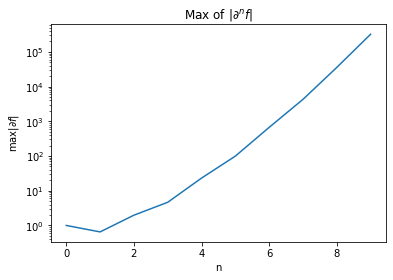

In [12]:
# Plot max(abs(fn)) in the range -5,5
z = np.linspace(-5, 5, 100)

Nmax = 10
maxValFn = np.zeros(Nmax)
for k in range(Nmax):
    maxValFn[k] = np.max(np.abs(diff_f(z)))
    
plt.plot(range(10), maxValFn)

plt.yscale('log')
plt.xlabel('n'); plt.ylabel('$\max|\partial f|$');
plt.title('Max of $|\partial^n f|$');
plt.show()

### Interpolation de Chebyshev


Pour chaque entier positif $n\geq 1$, pour $i=0,\dots n$, on note
$$\hat{x}_i=-\cos(\pi i/n)\in[-1,1]$$
**les points de Chebyshev** et on définit

$$x_i=\dfrac{a+b}{2}+\dfrac{b-a}{2}\hat{x}_i\in[a,b],$$

pour un intervalle arbitraire $[a,b]$. Pour une fonction continue $f\in
C^1([a,b])$, le polynôme d'interpolation $\Pi_n f$ de degré $n$ aux noeuds
$\{x_i,i=0,\ldots,n\}$ converge uniformément vers $f$ quand
$n\rightarrow \infty$.



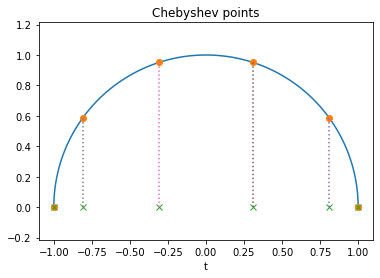

In [13]:
# Chebichev points on the interval [-1,1]

z = np.linspace(0,1, 100)
plt.plot(np.cos(np.pi*z), np.sin(np.pi*z))

n =5
z = np.linspace(0,1, n+1)
plt.plot(np.cos(np.pi*z), np.sin(np.pi*z), 'o')
plt.plot(np.cos(np.pi*z), 0*z, 'x')

for k in range(0,n+1) :
    plt.plot([np.cos(np.pi*z[k]),np.cos(np.pi*z[k])],[0,np.sin(np.pi*z[k])],':')

plt.axis('equal')

plt.xlabel('t'); 
plt.title('Chebyshev points')
plt.show()


#### Exemple

On reprend le
  même exemple mais on interpole la fonction de Runge dans les points de
Chebyshev. La figure montre les polynômes de
Chebyshev de degrés $n=5$ et $n=10$. On remarque que les oscillations
diminuent lorsqu'on augmente le degré du polynôme.



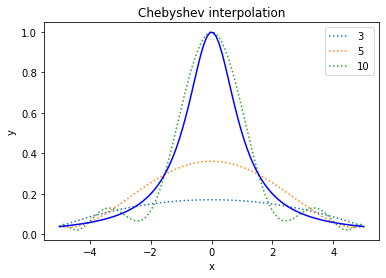

In [14]:
# Runge fonction
f = lambda x : 1./(1+x**2)

# Values of N to use
Nrange = [3,5,10]
# plotting points
[a,b] = [-5,5]
z = np.linspace(a,b, 100)

for n in Nrange :

    # Chebyshev points on [-1,1]
    hx = -np.cos(np.pi*np.linspace(0,n,n+1)/n)
    # mapped to [a,b]
    x =(a+b)/2 + (b-a)/2*hx

    y = f(x)

    plt.plot(z, LagrangePi(x,y,z), ':')

plt.plot(z,f(z), 'b')
plt.xlabel('x'); plt.ylabel('y'); plt.title('Chebyshev interpolation')
plt.legend(Nrange)
plt.show()